# ENEM 2025: da inscrição ao contexto econômico

O Inep confirmou **4.811.338 inscrições**. Os microdados divulgam **4.810.772 registros em PARTICIPANTES** e o mesmo total em RESULTADOS: **566 a menos**, sem causa estabelecida para a diferença. [Balanço oficial de 09/11/2025](https://download.inep.gov.br/enem/outros_documentos/enem_balanco_da_aplicacao_09_11_2025.pdf) e [confirmação oficial de 11/08/2025](https://www.gov.br/mulheres/pt-br/central-de-conteudos/noticias/2025/agosto/mulheres-lideram-inscricoes-no-enem-2025-e-somam-60-dos-participantes). Consulta registrada em 22/09/2026; a tabela do balanço foi recuperada pelo índice de busca.

A história começa pela participação nos dois dias, segue pelas notas e seus recortes e termina no contexto econômico. **Participação e desempenho usam RESULTADOS; renda usa PARTICIPANTES, de forma independente.** Igualdade de volume não cria uma chave comum entre as bases.


In [1]:
from pathlib import Path
import sys
import json
import hashlib
import pandas as pd
from IPython.display import display, Image

raiz = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/participacao_graficos.py").is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from src.participacao_graficos import gerar_graficos_participacao, numero, porcentagem, NOMES

def conferir_hash(caminho, esperado):
    with caminho.open("rb") as arquivo:
        obtido = hashlib.file_digest(arquivo, "sha256").hexdigest()
    if obtido != esperado:
        raise ValueError(f"Arquivo diverge da auditoria: {caminho.name}")

auditoria_participacao = json.loads((raiz / "reports/validacao_participacao_2025.json").read_text(encoding="utf-8"))
auditoria_notas = json.loads((raiz / "reports/validacao_desempenho_2025.json").read_text(encoding="utf-8"))
conferir_hash(raiz / "trusted/resultados_2025_base.parquet", auditoria_participacao["sha256_depois"])
assert auditoria_participacao["sha256_depois"] == auditoria_notas["sha256_fonte_depois"]
for nome, esperado in auditoria_participacao["hashes_csv"].items():
    conferir_hash(raiz / "analitica" / nome, esperado)
conferir_hash(raiz / "analitica/desempenho_2025.csv", auditoria_notas["sha256_indicadores_csv"])
participacao = auditoria_participacao["resultado"]
resumo_dias = participacao["resumo"]
assert (resumo_dias["total_base"], resumo_dias["presentes_dia1"], resumo_dias["presentes_dia2"], resumo_dias["presentes_ambos"]) == (4810772, 3457555, 3260336, 3244348)
tabela = pd.read_csv(raiz / "analitica/desempenho_2025.csv")
figuras_participacao = gerar_graficos_participacao(participacao, raiz / "apresentacao/graficos")
from src.redacao_graficos import gerar_graficos_redacao
auditoria_redacao = json.loads((raiz / "reports/validacao_redacao_2025.json").read_text(encoding="utf-8"))
inscritos = json.loads((raiz / "reports/validacao_inscritos_2025.json").read_text(encoding="utf-8"))
assert auditoria_redacao["sha256_depois"] == auditoria_participacao["sha256_depois"] == inscritos["sha256_resultados"]
assert inscritos["oficial"]["inscricoes_confirmadas"] == 4811338
assert inscritos["participantes"]["registros"] == inscritos["registros_resultados"] == 4810772
for nome, esperado in auditoria_redacao["hashes_csv"].items():
    conferir_hash(raiz / "analitica" / nome, esperado)
redacao = auditoria_redacao["resultado"]
assert (redacao["final"][0]["n"], redacao["final"][0]["zeros"], redacao["final"][0]["mediana"]) == (3457555, 211859, 600)
assert auditoria_redacao["controles"]["recorte_competencias"] == 3245696
figuras_redacao = gerar_graficos_redacao(redacao, raiz / "apresentacao/graficos")

from src.local_prova_graficos import gerar_grafico_local_prova
auditoria_local=json.loads((raiz/'reports/validacao_local_prova_2025.json').read_text(encoding='utf-8'))
assert auditoria_local['sha256_depois']==auditoria_participacao['sha256_depois']
conferir_hash(raiz/'docs/uf_regiao_ibge.json',auditoria_local['sha256_referencia'])
for nome,esperado in auditoria_local['hashes_csv'].items():
    conferir_hash(raiz/'analitica'/nome,esperado)
territorial=auditoria_local['resultado']
assert auditoria_local['controles']['cobertura']['registros_uf_regiao_valida']==4810772
assert auditoria_local['controles']['cobertura']['registros_nao_classificados']==0
figura_local=gerar_grafico_local_prova(territorial,raiz/'apresentacao/graficos')

from src.rede_escolar_graficos import gerar_grafico_rede_escolar
auditoria_rede=json.loads((raiz/'reports/validacao_rede_escolar_2025.json').read_text(encoding='utf-8'))
assert auditoria_rede['sha256_antes']==auditoria_rede['sha256_depois']==auditoria_participacao['sha256_depois']
for nome,esperado in auditoria_rede['hashes_csv'].items():
    conferir_hash(raiz/'analitica'/nome,esperado)
escolar=auditoria_rede['resultado']
assert (auditoria_rede['controles']['total_base'],auditoria_rede['controles']['rede_valida'],auditoria_rede['controles']['rede_nula'],auditoria_rede['controles']['rede_invalida'])==(4810772,1739028,3071744,0)
assert [r['registros'] for r in escolar['cobertura']]==[74649,1382565,9015,272799,3071744]
assert [r['mediana'] for r in escolar['desempenho'] if r['area']=='MT']==[588.5,462.3,528.1,627.4]
figura_rede=gerar_grafico_rede_escolar(escolar,raiz/'apresentacao/graficos')

from src.perfil_economico import CATEGORIAS
from src.perfil_economico_graficos import gerar_graficos_perfil_economico
economico=pd.read_csv(raiz/'analitica/perfil_economico_2025.csv',keep_default_na=False).to_dict('records')
for pergunta,categorias in CATEGORIAS.items():
    linhas=[r for r in economico if r['pergunta']==pergunta]
    assert [r['codigo'] for r in linhas]==[*categorias,'']
    assert sum(r['quantidade'] for r in linhas)==inscritos['participantes']['registros']
    assert all(r['total_base']==inscritos['participantes']['registros'] and r['sha256_fonte']==inscritos['sha256_depois'] for r in linhas)
    assert all(r['respostas_validas']+r['sem_resposta']==r['total_base'] for r in linhas)
    assert all(abs(r['percentual_base']-100*r['quantidade']/r['total_base'])<1e-10 for r in linhas)
assert next(r['quantidade'] for r in economico if r['pergunta']=='Q006' and r['codigo']=='A')==3454810
assert sum(r['quantidade'] for r in economico if r['pergunta']=='Q007' and r['codigo'] in ['A','B','C','D'])==3424548
figuras_economicas=gerar_graficos_perfil_economico(economico,raiz/'apresentacao/graficos')


## O segundo dia teve 197.219 presenças completas a menos

Dos **4.810.772 registros de RESULTADOS**, **3.457.555 (71,87%)** tiveram presença completa no primeiro dia e **3.260.336 (67,77%)**, no segundo. Presença completa exige as duas áreas do dia: LC+CH e CN+MT, respectivamente. Nesta base, os pares concordam em todos os registros.


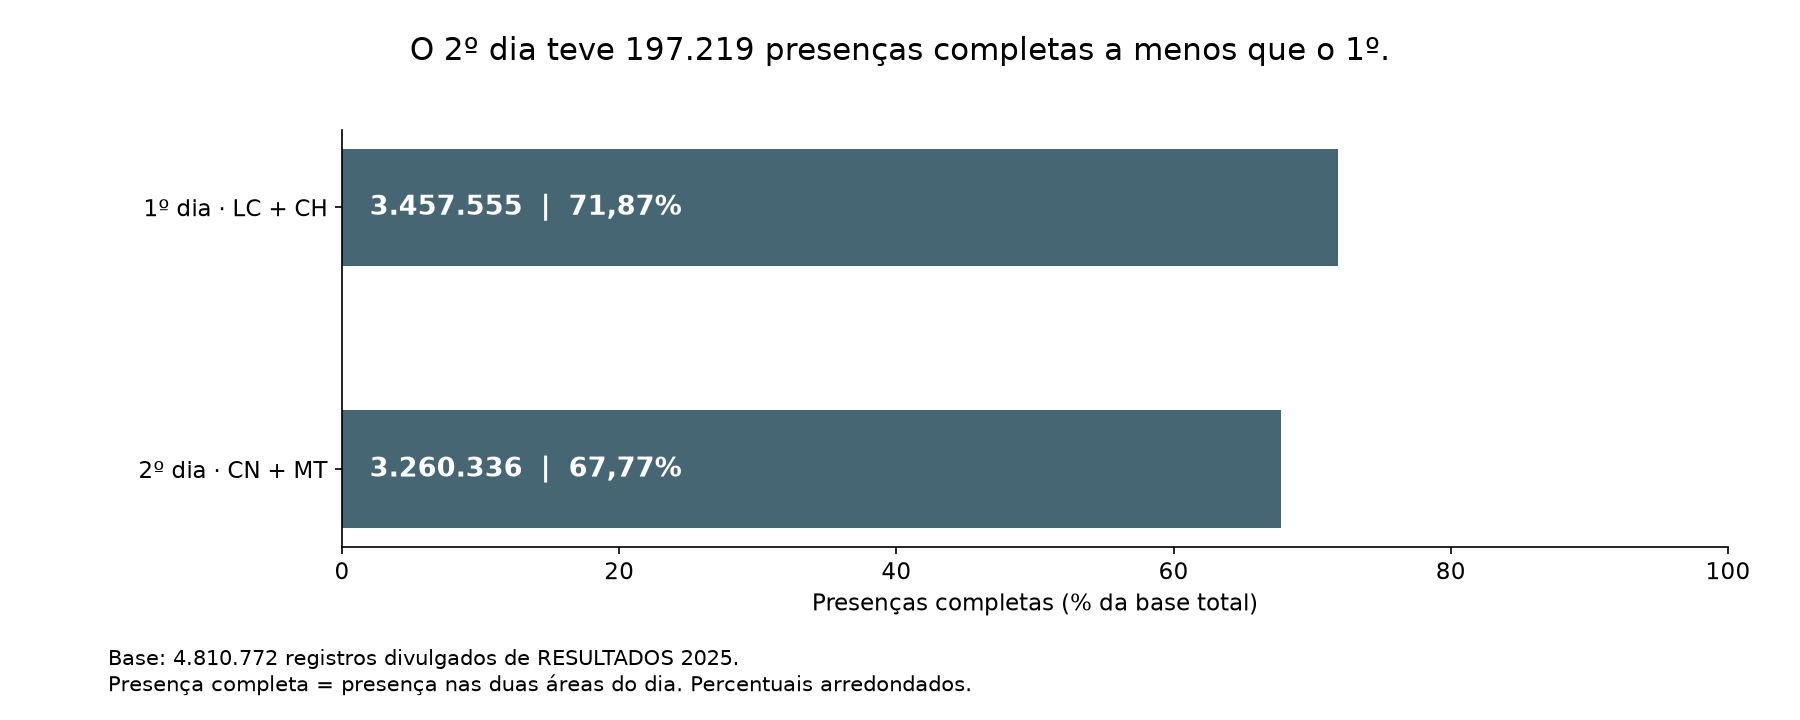

In [2]:
display(Image(filename=str(figuras_participacao[0])))

## 93,83% dos presentes no primeiro dia voltaram no segundo

O total por dia não mostra quem continuou. O fluxo abaixo acompanha os mesmos registros: **3.244.348** tiveram presença completa nos dois dias, entre **3.457.555 presentes no primeiro**. Esse é o denominador da retenção.

O caminho laranja destaca os **211.292** que passaram de presença completa para ausência completa. Ele não é igual à redução líquida entre dias.


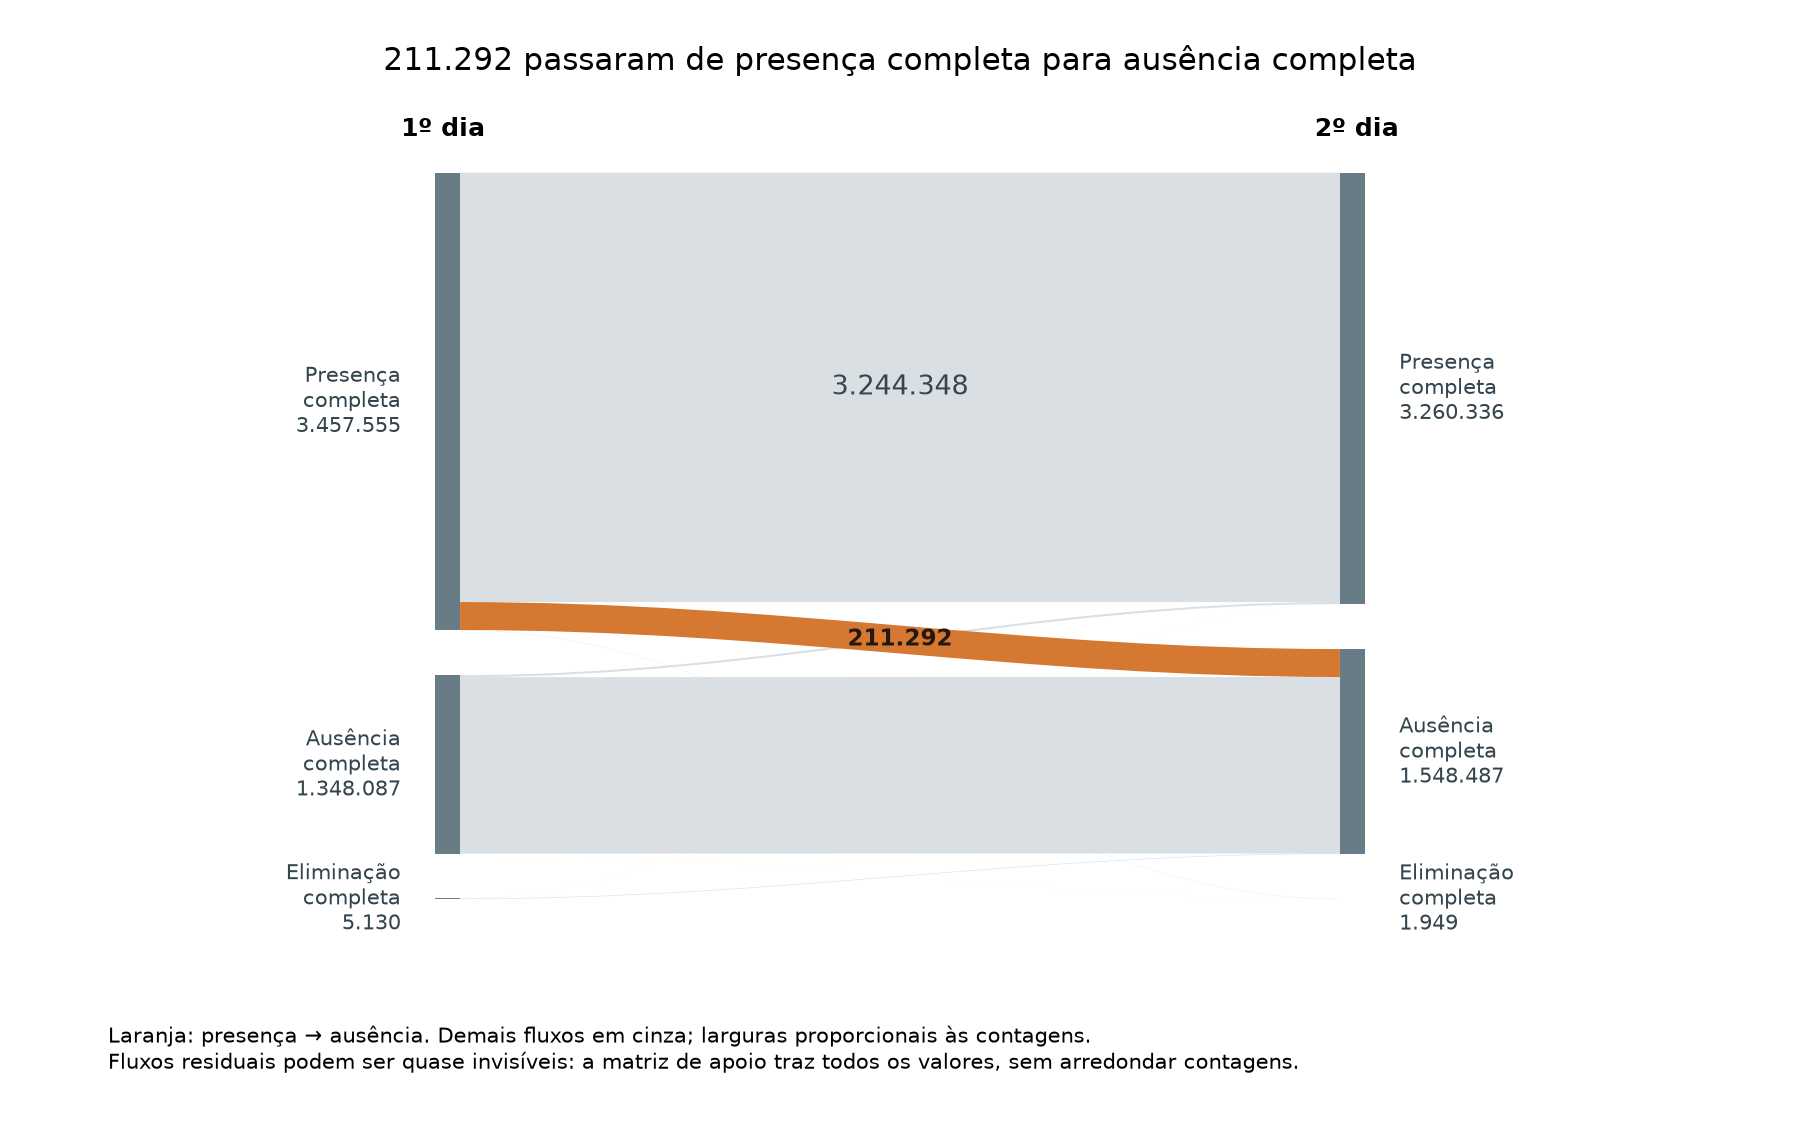

In [3]:
display(Image(filename=str(figuras_participacao[1])))

### Todos os caminhos, com a mesma base de comparação

Cada célula traz **contagem | % dos 4.810.772 registros**. Situações mistas, campos ausentes e códigos inválidos não ocorreram nos pares de presença desta base. Percentuais positivos menores que 0,01% permanecem visíveis.


In [4]:
estados = ["presente", "ausente", "eliminado"]
celulas = {(x["dia1"], x["dia2"]): x for x in participacao["transicoes"]}
matriz = pd.DataFrame(
    [[f"{numero(celulas[a, b]['quantidade'])} | {porcentagem(celulas[a, b]['percentual_base'])}" for b in estados] for a in estados],
    index=[NOMES[a] for a in estados], columns=[NOMES[b] for b in estados])
matriz.index.name = "1º dia → 2º dia"
display(matriz)

,Presença completa,Ausência completa,Eliminação completa
1º dia → 2º dia,,,
Presença completa,"3.244.348 | 67,44%","211.292 | 4,39%","1.915 | 0,04%"
Ausência completa,"15.146 | 0,31%","1.332.913 | 27,71%","28 | <0,01%"
Eliminação completa,"842 | 0,02%","4.282 | 0,09%","6 | <0,01%"


A redução líquida combina entradas e saídas: **15.146 + 842 − 211.292 − 1.915 = −197.219**. Os 842 e 1.915 correspondem a mudanças envolvendo eliminação, mantidas separadas das ausências. O fluxo descreve o que foi registrado, sem explicar os motivos.


## Da presença às notas de quem participou

Em cada área, incluímos **presença=1 e nota disponível, mantendo zero**. Não é necessário ter nota nas outras áreas. São **3.260.336 notas por área em Natureza/Matemática** e **3.457.555 em Humanas/Linguagens**.


### Em Matemática, os 50% centrais ficaram entre 416,5 e 606,8

A mediana foi **500,0** e a média, **519,98**. No gráfico, a faixa mostra Q1–Q3, o ponto marca a mediana e a linha fina vai do mínimo ao máximo observado. Cada área tem sua própria escala; não interpretamos essas notas como um ranking de dificuldade.


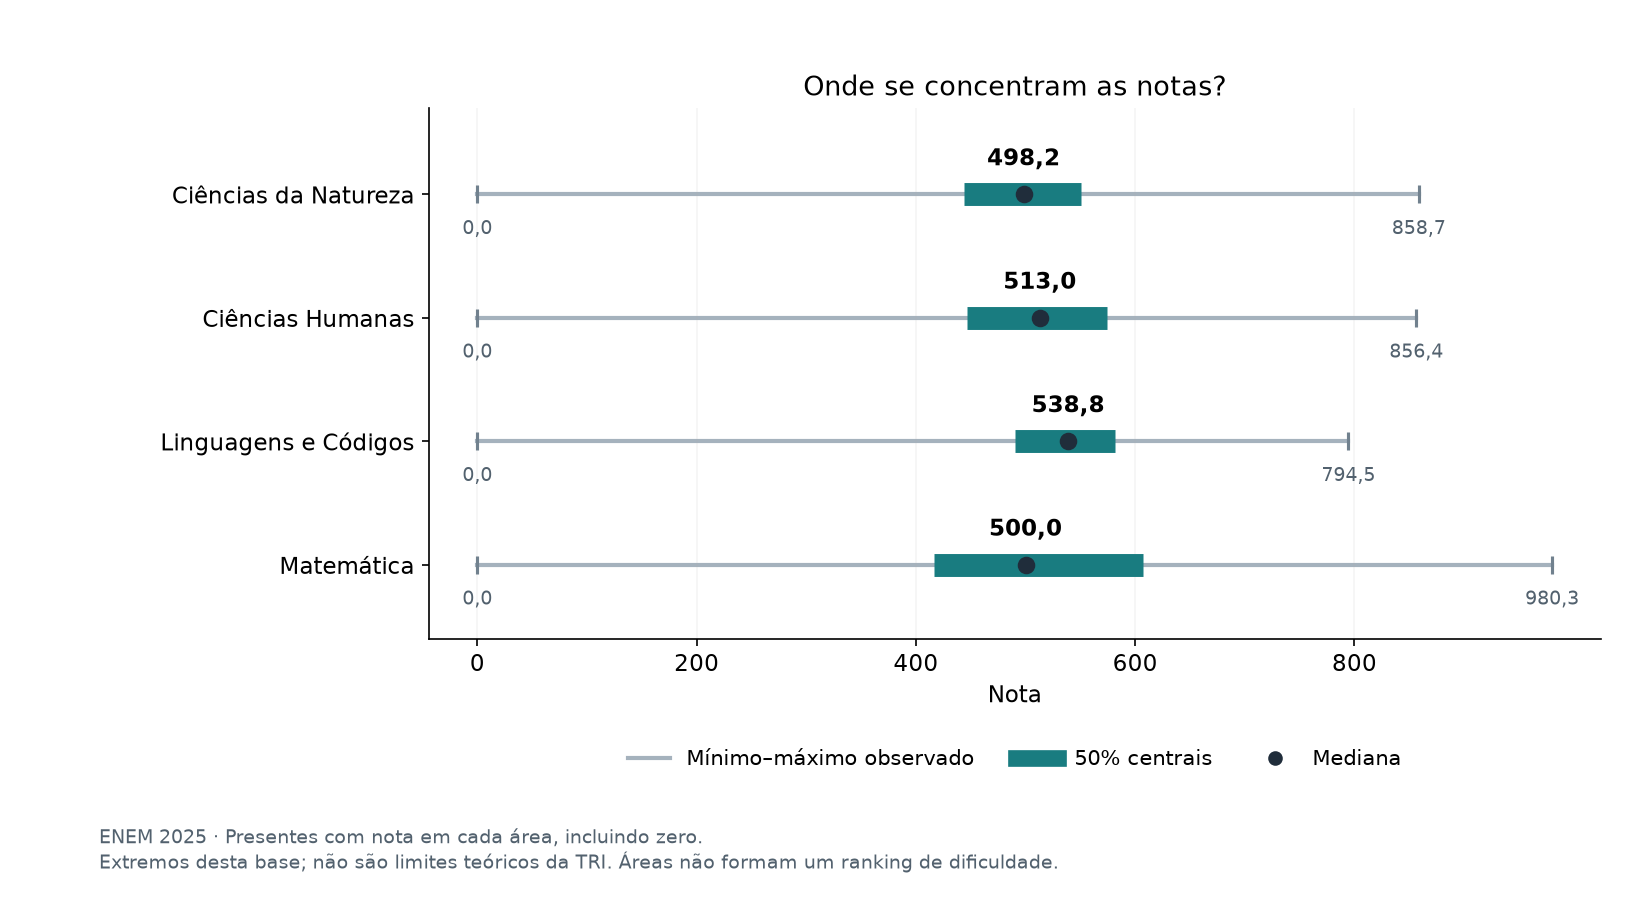

In [5]:
display(Image(filename=str(raiz / "apresentacao/graficos/quartis_por_area_2025.png")))

In [6]:
colunas = {"nome_area":"Área", "elegiveis":"Notas analisadas", "minimo_observado":"Mínimo observado", "q1":"Q1", "mediana":"Mediana", "q3":"Q3", "maximo_observado":"Máximo observado", "media":"Média"}
display(tabela[list(colunas)].rename(columns=colunas).round(2))

,Área,Notas analisadas,Mínimo observado,Q1,Mediana,Q3,Máximo observado,Média
0,Ciências da Natureza,3260336,0.0,443.5,498.2,550.9,858.7,499.97
1,Ciências Humanas,3457555,0.0,446.6,513.0,574.0,856.4,511.19
2,Linguagens e Códigos,3457555,0.0,490.3,538.8,581.6,794.5,532.12
3,Matemática,3260336,0.0,416.5,500.0,606.8,980.3,519.98


Mínimos e máximos são **observados nesta base**, não limites teóricos da prova. As notas zero foram preservadas, sem atribuir uma causa a elas. A TRI não tem uma escala universal fixa de 0 a 1000; [o guia do Inep explica a interpretação](https://www.gov.br/inep/pt-br/centrais-de-conteudo/acervo-linha-editorial/publicacoes-institucionais/avaliacoes-e-exames-da-educacao-basica/entenda-a-sua-nota-no-enem-guia-do-participante).


## Na redação, a mediana foi 600 e os 50% centrais ficaram entre 480 e 720

Passamos das provas objetivas à escrita, que tem critérios e escala próprios. Há **3.457.555 notas finais**, com média **580,80**, incluindo **211.859 zeros**. Os **1.353.217 registros sem nota** ficam fora da distribuição; não viram zero.


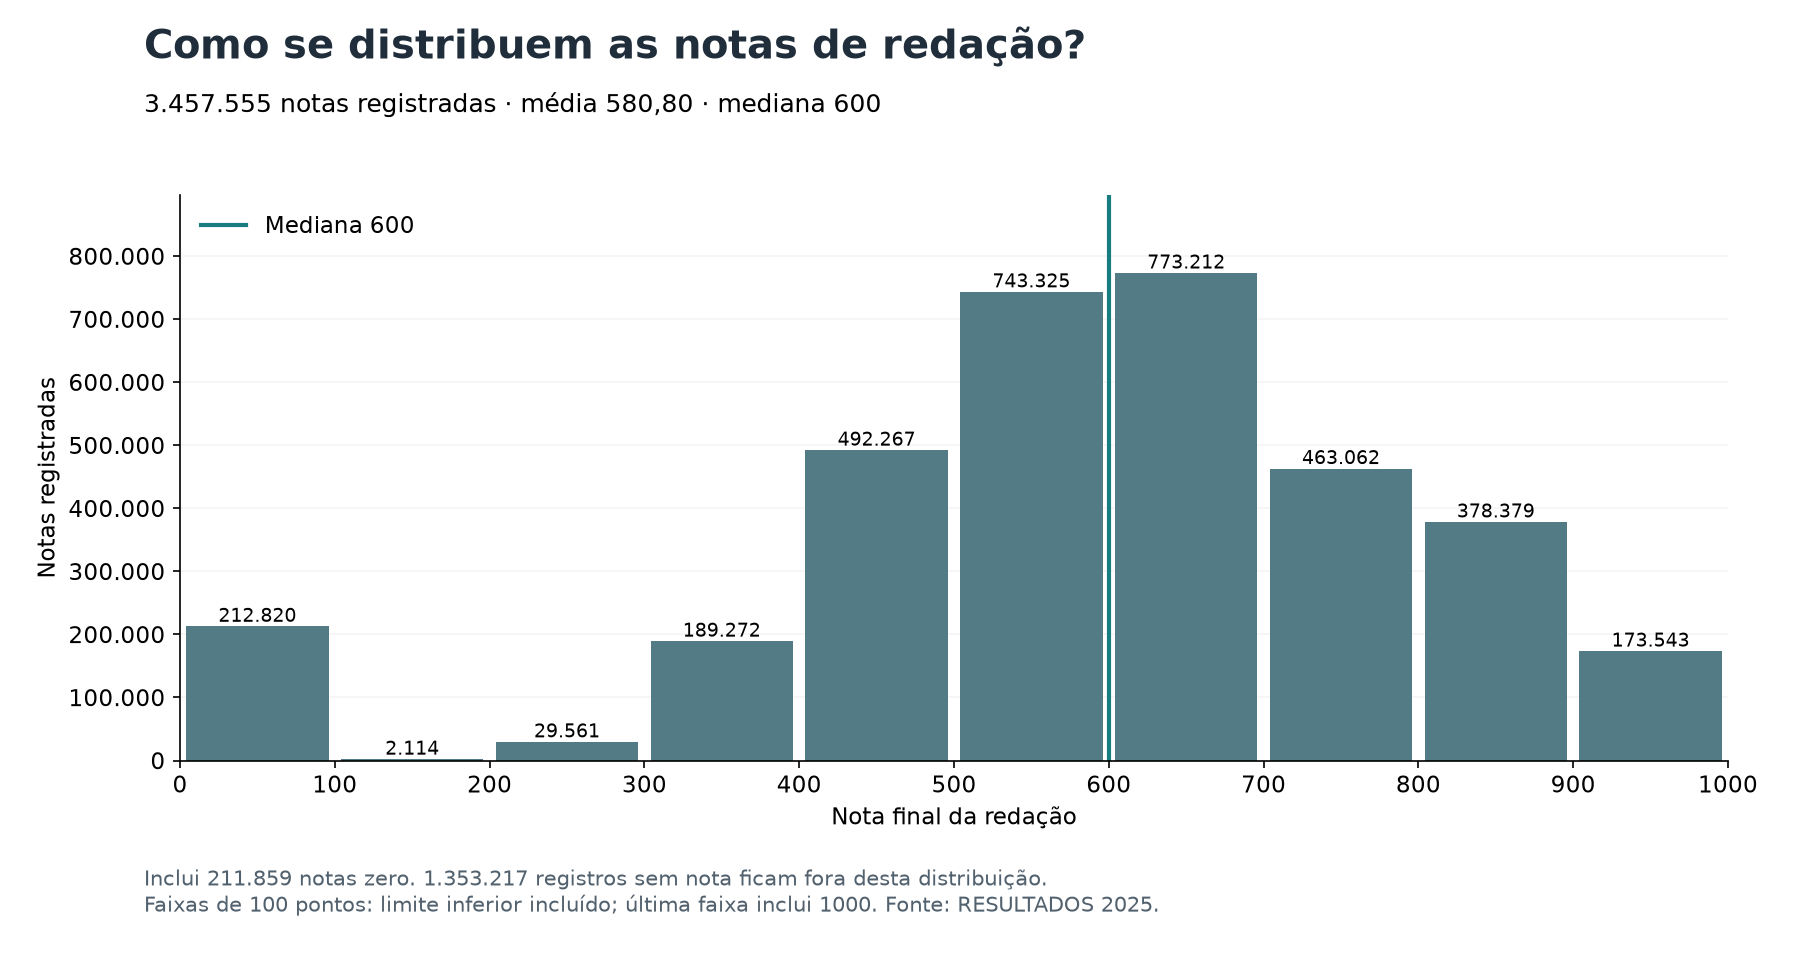

In [7]:
display(Image(filename=str(figuras_redacao[0])))


### Zero, redação em branco e nota ausente são situações distintas

A tabela usa **toda a base de 4.810.772 registros**. Os zeros finais aparecem nos status diferentes de “Sem problemas” e continuam na distribuição. Os registros sem nota também estão sem status; essa ausência não é uma nota nem uma situação de redação em branco.


In [8]:
colunas_status = {"situacao":"Situação registrada", "quantidade":"Registros", "percentual_base":"% da base total", "zeros":"Notas zero", "sem_nota":"Sem nota"}
display(pd.DataFrame(redacao["status"])[list(colunas_status)].rename(columns=colunas_status).round(2))


,Situação registrada,Registros,% da base total,Notas zero,Sem nota
0,Sem problemas,3245696,67.47,0,0
1,Anulada,3070,0.06,3070,0
2,Cópia Texto Motivador,54840,1.14,54840,0
3,Em Branco,114329,2.38,114329,0
4,Fuga ao tema,13576,0.28,13576,0
5,Não atendimento ao tipo textual,5661,0.12,5661,0
6,Texto insuficiente,16975,0.35,16975,0
7,Parte desconectada,3408,0.07,3408,0
8,Sem status registrado,1353217,28.13,0,1353217


### As cinco competências têm mediana 120 neste recorte

Para compará-las, usamos **3.245.696 redações “Sem problemas”, com nota final e as cinco competências disponíveis**. O denominador é comum e zeros individuais continuam incluídos.

As médias variam de **114,15 em C5 (proposta de intervenção)** a **136,97 em C2 (tema e tipo textual)**. Isso descreve esse recorte, sem diagnosticar causas individuais.


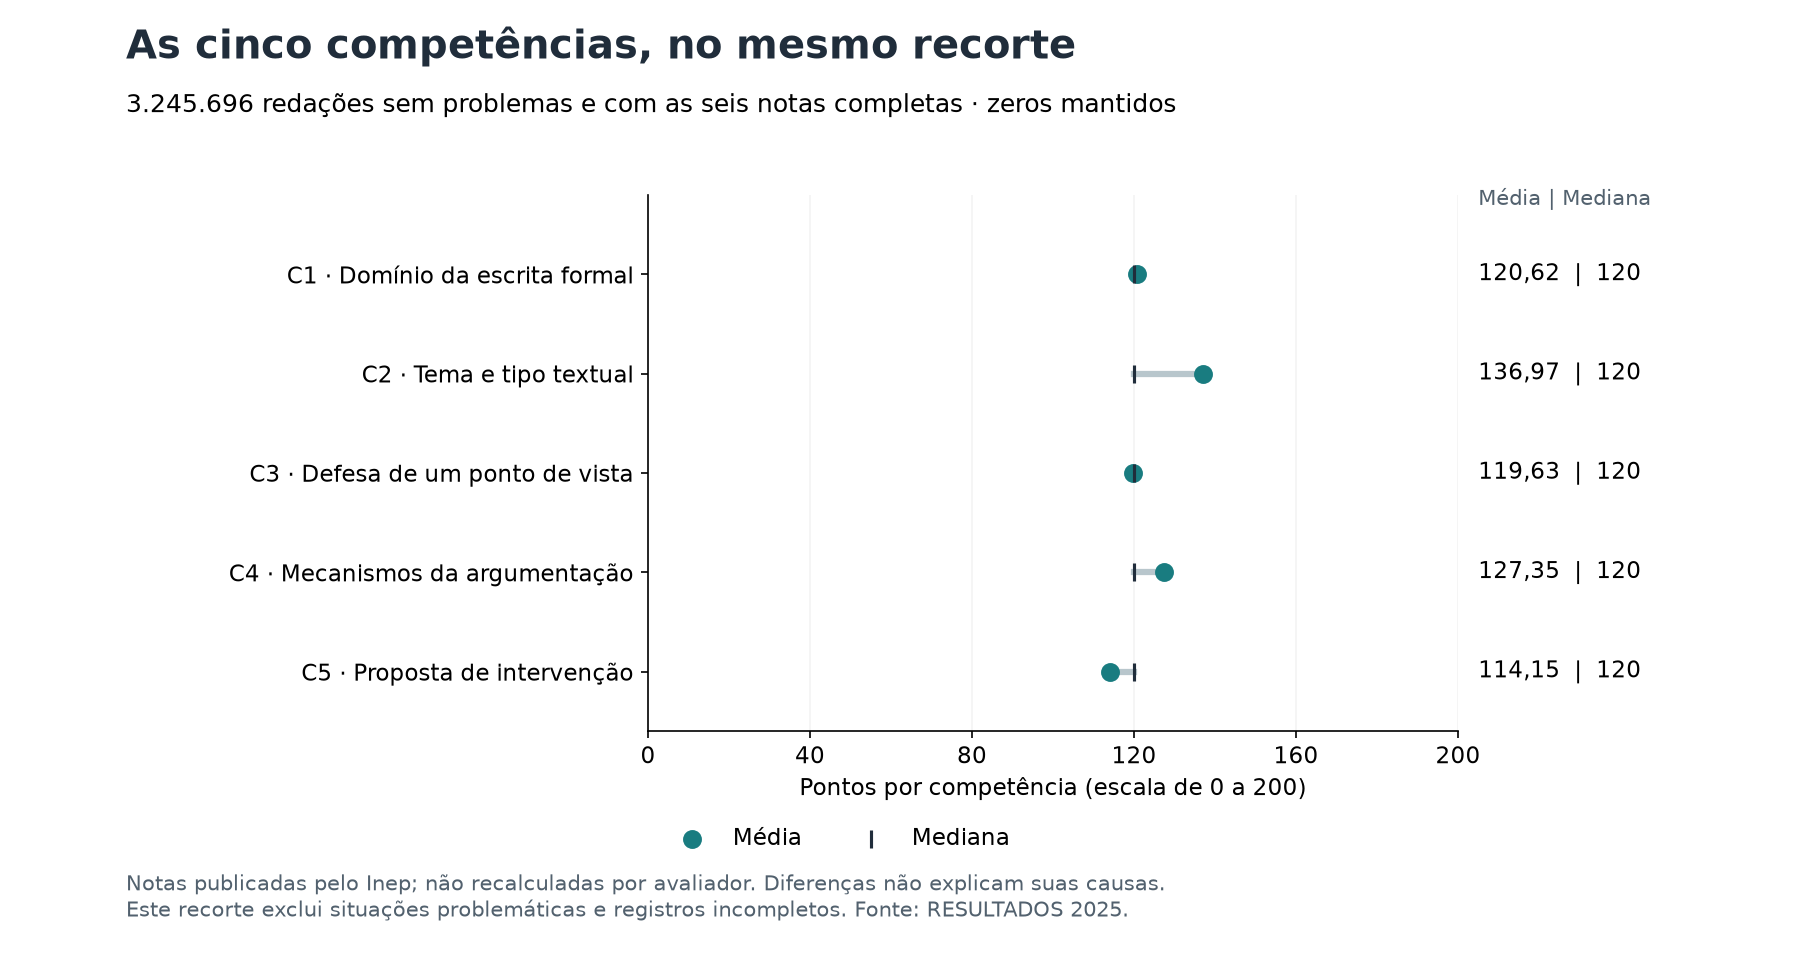

In [9]:
display(Image(filename=str(figuras_redacao[1])))


In [10]:
colunas_comp = {"competencia":"Competência", "n":"Redações analisadas", "media":"Média", "mediana":"Mediana", "q1":"Q1", "q3":"Q3", "zeros":"Notas zero"}
display(pd.DataFrame(redacao["competencias"])[list(colunas_comp)].rename(columns=colunas_comp).round(2))


,Competência,Redações analisadas,Média,Mediana,Q1,Q3,Notas zero
0,Domínio da escrita formal,3245696,120.62,120.0,100.0,140.0,589
1,Tema e tipo textual,3245696,136.97,120.0,120.0,160.0,0
2,Defesa de um ponto de vista,3245696,119.63,120.0,100.0,140.0,1072
3,Mecanismos da argumentação,3245696,127.35,120.0,100.0,160.0,1199
4,Proposta de intervenção,3245696,114.15,120.0,80.0,160.0,305510


As competências somam a nota final nos **3.457.555 registros comparáveis**. Usamos os valores publicados pelo Inep; o detalhamento de status e recortes está no notebook 04 e no contrato de redação.


## O local de aplicação acrescenta outro recorte às notas

Depois do panorama nacional, observamos as **cinco regiões de aplicação**. Todos os **4.810.772 registros** têm UF/região classificada; o mapeamento das 27 UFs usa a [referência oficial do IBGE](https://servicodados.ibge.gov.br/api/v1/localidades/estados?orderBy=id), preservada no projeto.

Local de prova **não é residência**. Mantemos a mesma regra de elegibilidade por área, com zeros incluídos; os tamanhos das bases estão na tabela de apoio.


### Em Matemática, a mediana foi 541,4 no Sudeste e 446,2 no Norte

Os intervalos centrais dessas regiões foram **447,4–644,7** e **389,0–530,6**, com sobreposição parcial. O gráfico permite comparar cada região **dentro de uma área**, sem atribuir qualidade educacional ou efeito causal ao território.

Médias e quartis vêm diretamente dos registros, não de médias ou quartis das UFs. A tabela mantém o número de notas elegíveis por região e área.


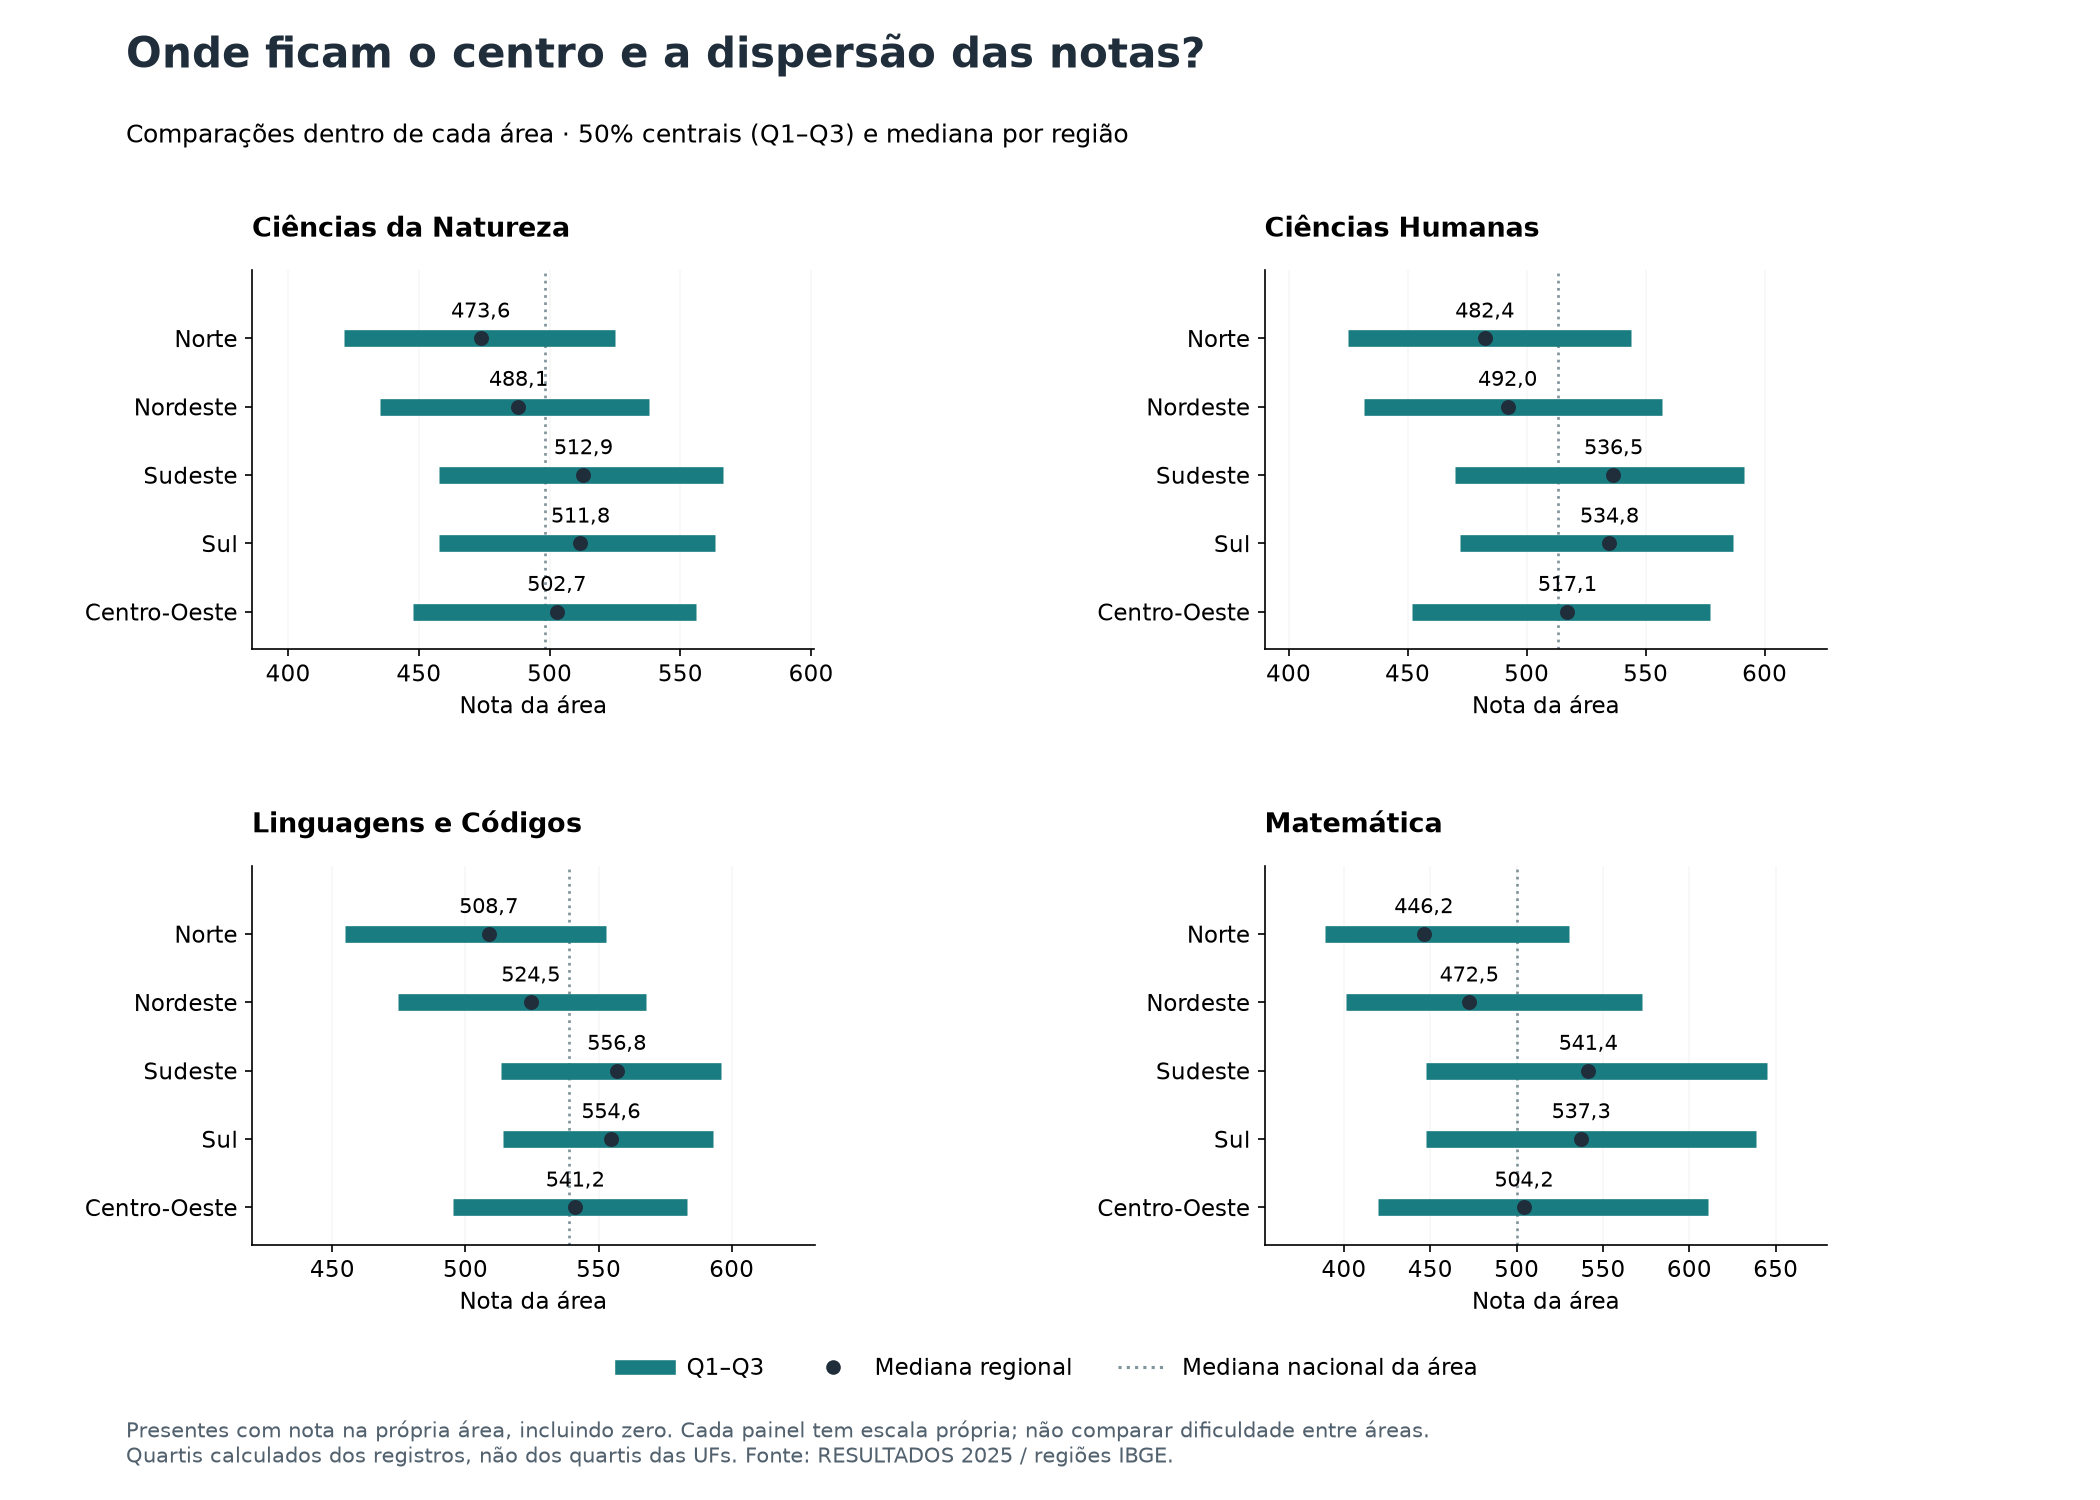

In [11]:
display(Image(filename=str(figura_local)))


In [12]:
notas_local=pd.DataFrame(territorial['desempenho'])
colunas_notas_local={'local':'Região de aplicação','area':'Área','elegiveis':'Notas elegíveis','media':'Média','mediana':'Mediana','q1':'Q1','q3':'Q3'}
display(notas_local[notas_local.nivel=='Região'][list(colunas_notas_local)].rename(columns=colunas_notas_local).round(2))


,Região de aplicação,Área,Notas elegíveis,Média,Mediana,Q1,Q3
4,Centro-Oeste,CN,253159,504.70,502.7,447.70,556.0
5,Nordeste,CN,1225462,489.94,488.1,435.10,538.2
6,Norte,CN,351465,476.21,473.6,421.20,525.0
7,Sudeste,CN,1102581,513.94,512.9,457.80,566.3
8,Sul,CN,327669,512.32,511.8,457.80,563.4
9,Centro-Oeste,CH,271902,514.91,517.1,451.70,576.9
10,Nordeste,CH,1285359,495.83,492.0,431.80,556.7
11,Norte,CH,377494,485.87,482.4,424.90,543.7
12,Sudeste,CH,1168120,530.15,536.5,470.00,591.2
13,Sul,CH,354680,528.50,534.8,472.10,586.6


Presença, permanência, transições e tabelas completas das UFs continuam disponíveis no **notebook 05** e nos CSVs `analitica/local_prova_2025_*.csv`. Aqui concentramos a leitura nas distribuições regionais de notas.


## Rede escolar está informada em 36,15% da base

**Além do lugar de aplicação, o que muda quando observamos a rede da escola informada?** A comparação usa **1.739.028 registros com rede válida**; os **3.071.744 sem informação (63,85%)** não são atribuídos a nenhuma rede. Não houve código inválido.

O vínculo escolar vem do **Censo Escolar 2025**, com seleção de etapas de possíveis concluintes e critérios para múltiplas matrículas, incluindo preferência por rede pública. É um recorte selecionado, não todos os participantes ou alunos de cada rede. Federal é pública; as quatro categorias ficam separadas.


In [13]:
colunas_cobertura={'rede':'Rede informada','registros':'Registros na base','pct_base':'% de toda a base'}
tabela_cobertura=pd.DataFrame(escolar['cobertura'])[list(colunas_cobertura)].rename(columns=colunas_cobertura)
tabela_cobertura['Registros na base']=tabela_cobertura['Registros na base'].map(numero)
tabela_cobertura['% de toda a base']=tabela_cobertura['% de toda a base'].map(porcentagem)
display(tabela_cobertura)


,Rede informada,Registros na base,% de toda a base
0,Federal,74.649,"1,55%"
1,Estadual,1.382.565,"28,74%"
2,Municipal,9.015,"0,19%"
3,Privada,272.799,"5,67%"
4,Sem informação,3.071.744,"63,85%"


### Em Matemática, as medianas vão de 462,3 a 627,4 nas redes informadas

São **588,5 na Federal, 462,3 na Estadual, 528,1 na Municipal e 627,4 na Privada**. As faixas centrais se sobrepõem: Federal **489,4–680,4** e Privada **525,9–715,4**, por exemplo.

A regra continua sendo presença e nota disponível na própria área, incluindo zero. A **Municipal tem base menor**: 9.015 registros, com 6.619 notas em Natureza/Matemática e 6.952 em Humanas/Linguagens. Os denominadores de todas as redes ficam na tabela.


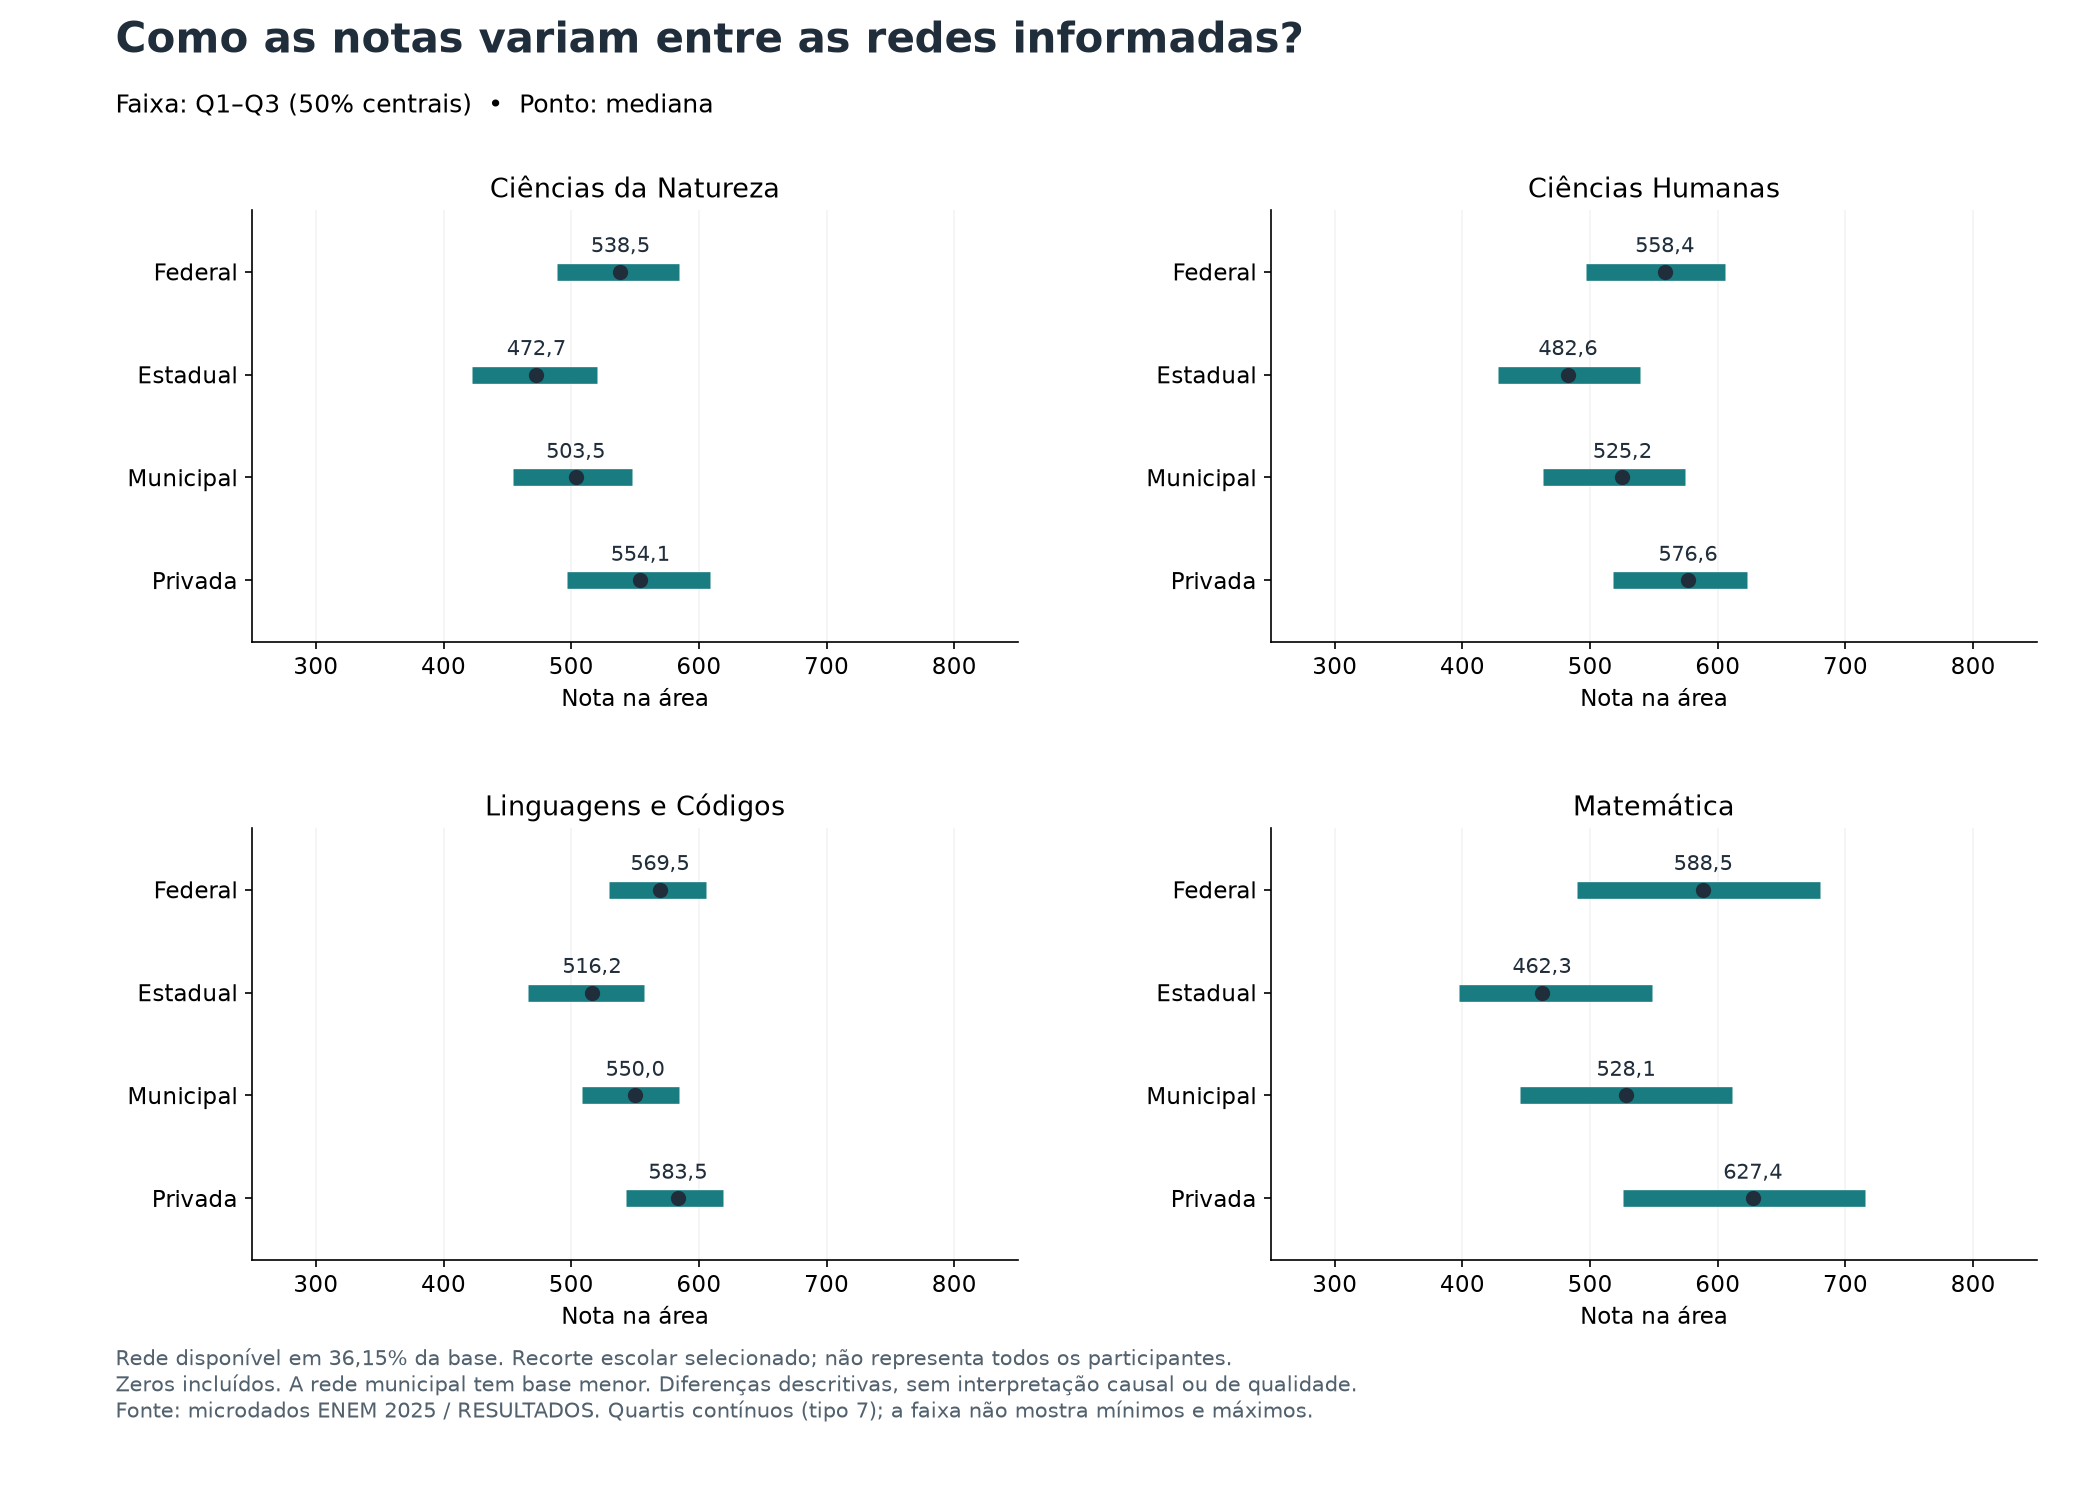

In [14]:
display(Image(filename=str(figura_rede)))


In [15]:
colunas_rede={'rede':'Rede','nome_area':'Área','elegiveis':'Notas elegíveis','media':'Média','q1':'Q1','mediana':'Mediana','q3':'Q3'}
tabela_rede=pd.DataFrame(escolar['desempenho'])[list(colunas_rede)].rename(columns=colunas_rede)
tabela_rede['Notas elegíveis']=tabela_rede['Notas elegíveis'].map(numero)
for coluna in ['Média','Q1','Mediana','Q3']:
    tabela_rede[coluna]=tabela_rede[coluna].map(lambda x:f'{x:.2f}'.replace('.',','))
display(tabela_rede)


,Rede,Área,Notas elegíveis,Média,Q1,Mediana,Q3
0,Federal,Ciências da Natureza,68.618,"535,70","489,20","538,50","584,30"
1,Federal,Ciências Humanas,70.097,"547,87","497,00","558,40","605,40"
2,Federal,Linguagens e Códigos,70.097,"563,98","529,30","569,50","605,60"
3,Federal,Matemática,68.618,"586,95","489,40","588,50","680,40"
4,Estadual,Ciências da Natureza,964.885,"472,61","422,60","472,70","520,20"
5,Estadual,Ciências Humanas,1.018.248,"483,67","427,70","482,60","539,40"
6,Estadual,Linguagens e Códigos,1.018.248,"508,20","466,40","516,20","557,00"
7,Estadual,Matemática,964.885,"480,63","397,40","462,30","548,60"
8,Municipal,Ciências da Natureza,6.619,"500,20","454,40","503,50","547,70"
9,Municipal,Ciências Humanas,6.952,"517,05","462,78","525,25","574,42"


Essas diferenças não medem efeito ou qualidade da escola. Seleção, composição e participação não foram ajustadas; **rede não é um indicador de renda**. O notebook 06 e o contrato de rede escolar detalham o recorte.


## Das notas ao contexto econômico dos inscritos

Para encerrar, mudamos de fonte: **PARTICIPANTES 2025**, analisada de forma independente de RESULTADOS. Não ligamos renda às notas ou à rede escolar.

São **4.810.772 registros divulgados**, não as 4.811.338 inscrições confirmadas do balanço oficial. Q006 e Q007 têm **100% de respostas válidas**, sem ausências ou códigos inesperados. Esse total é o denominador dos percentuais abaixo.


### 71,18% dos inscritos declararam renda familiar mensal de até R$ 3.036

São **3.424.548 de 4.810.772 registros**, somando as categorias **A–D** de Q007, **incluindo nenhuma renda**. O limite exato da faixa é **R$ 3.036**, não R$ 3.000. A proporção descreve inscritos/respondentes, não famílias únicas.

Q007 inclui a renda do inscrito e das pessoas que moram com ele. É **renda mensal familiar declarada, não per capita**, em faixas nominais de 2025. Não estimamos uma média a partir dessas faixas.


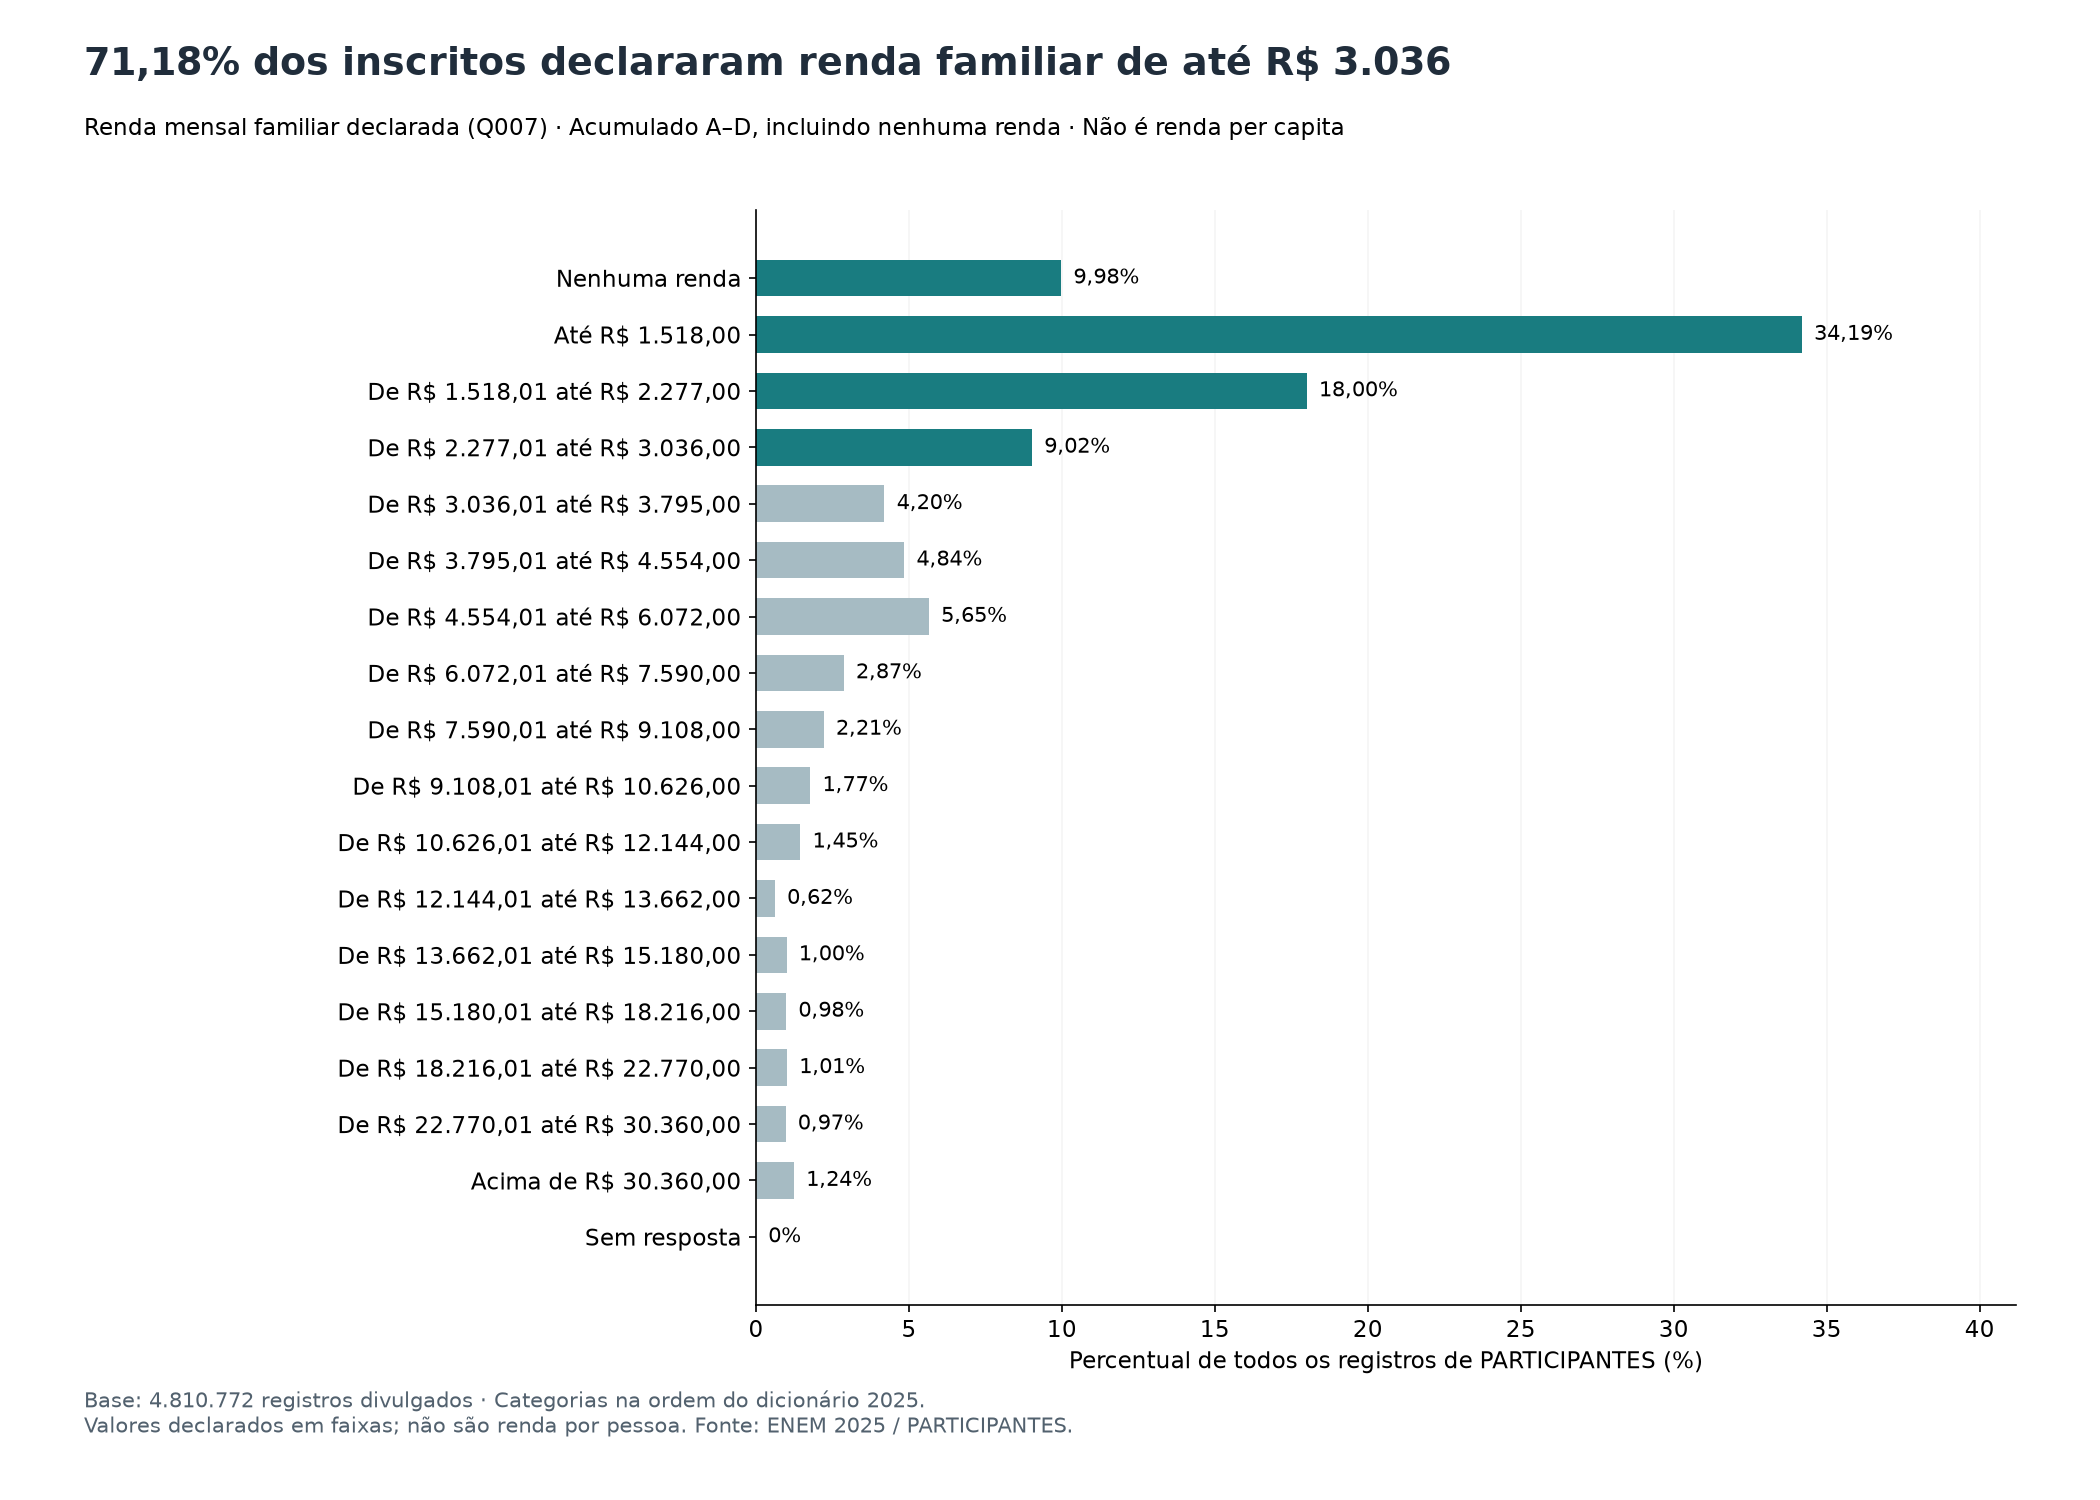

In [16]:
display(Image(filename=str(figuras_economicas[0])))


In [17]:
colunas_economicas={'categoria':'Renda mensal familiar declarada','quantidade':'Registros','percentual_base':'% da base'}
tabela_familiar=pd.DataFrame([r for r in economico if r['pergunta']=='Q007'])[list(colunas_economicas)].rename(columns=colunas_economicas)
tabela_familiar['Registros']=tabela_familiar['Registros'].map(numero)
tabela_familiar['% da base']=tabela_familiar['% da base'].map(porcentagem)
display(tabela_familiar)


,Renda mensal familiar declarada,Registros,% da base
0,Nenhuma renda,479.899,"9,98%"
1,"Até R$ 1.518,00",1.644.626,"34,19%"
2,"De R$ 1.518,01 até R$ 2.277,00",866.020,"18,00%"
3,"De R$ 2.277,01 até R$ 3.036,00",434.003,"9,02%"
4,"De R$ 3.036,01 até R$ 3.795,00",202.017,"4,20%"
5,"De R$ 3.795,01 até R$ 4.554,00",233.062,"4,84%"
6,"De R$ 4.554,01 até R$ 6.072,00",271.843,"5,65%"
7,"De R$ 6.072,01 até R$ 7.590,00",137.918,"2,87%"
8,"De R$ 7.590,01 até R$ 9.108,00",106.469,"2,21%"
9,"De R$ 9.108,01 até R$ 10.626,00",85.387,"1,77%"


### 71,81% declararam não possuir renda própria

Em Q006, **3.454.810** responderam **Não** e **1.355.962 (28,19%)**, **Sim**. A pergunta informa apenas se a pessoa declara possuir renda, sem valor recebido.

Não possuir renda própria não significa que a família não tenha renda, nem identifica emprego ou condição de estudante. A base não demonstra a causa dessa resposta; as duas distribuições não são combinadas para deduzir situações individuais.


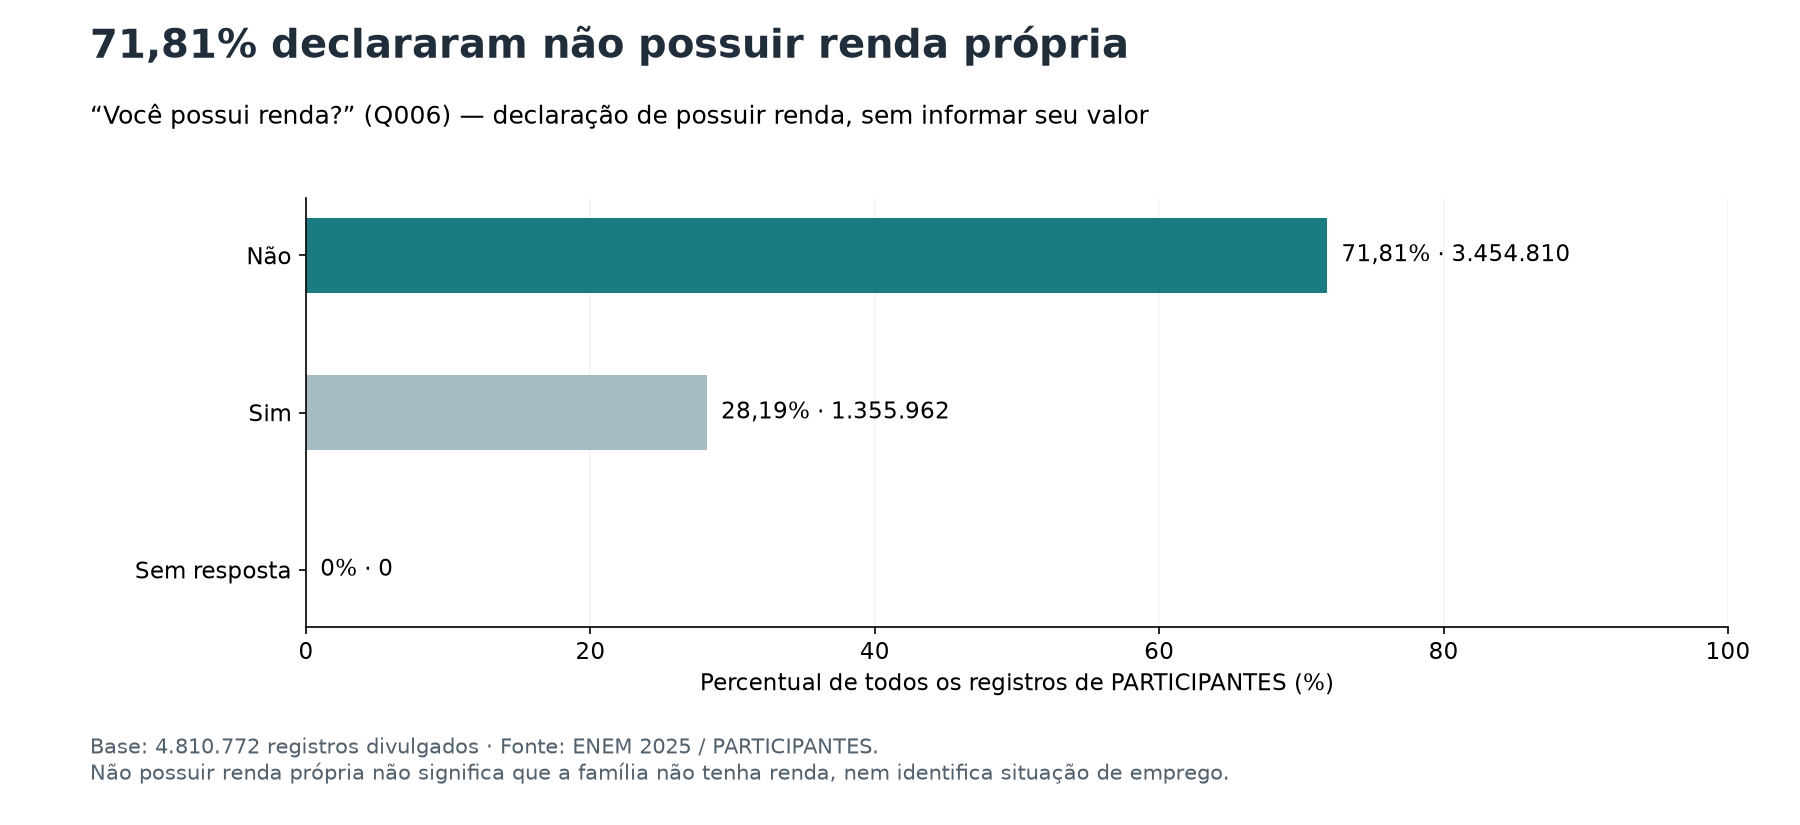

In [18]:
display(Image(filename=str(figuras_economicas[1])))


O perfil descreve os inscritos disponíveis nesta edição, não a população brasileira nem apenas quem compareceu. Categorias, quantidades, denominadores e ausências estão em `analitica/perfil_economico_2025.csv`; regras e processamento, no notebook 07.


## Uma leitura descritiva, com universos distintos

Acompanhamos a participação, as notas e seus recortes em RESULTADOS e, separadamente, o contexto econômico em PARTICIPANTES. As diferenças observadas não explicam motivos de ausência, qualidade das escolas ou efeito da renda sobre as notas.

A apresentação consome agregados; não reconstrói dados nem cria relatórios. Para reproduzir ou aprofundar a análise, consulte os notebooks de processamento, os contratos e o mapa do projeto no README. Cópias externas mantêm as saídas para leitura e dependem do projeto para executar.
